# Consumer Credit Analytics — Probability of Default Model
### ClarityPay Data Science Take-Home Exercise
### Hongxu Dong, 03/05/2026
**Objective:** Predict the probability of default (PD) at loan origination using only information available at the time of issuance.

**Dataset:** Lending Club 2007-2020

**Target Variable:** `loan_status` → `Charged Off` = 1 (default), `Fully Paid` = 0


---

## 0. Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

## 1. Data Loading

### Dataset: Lending Club 2007–2020
- **Source:** https://www.kaggle.com/datasets/ethon0426/lending-club-20072020q1

In [6]:
import kagglehub
import os

# 1. Download the dataset
path = kagglehub.dataset_download("ethon0426/lending-club-20072020q1")
print("Path to dataset files:", path)

# # 2. List files to find the exact CSV name
files = os.listdir(path)
print("Files in dataset:", files)

# # 3. Read the main CSV file (a huge gzip file)
csv_file = os.path.join(path, "Loan_status_2007-2020Q3.gzip")
raw = pd.read_csv(csv_file, low_memory=False)

Path to dataset files: /Users/hongxudong/.cache/kagglehub/datasets/ethon0426/lending-club-20072020q1/versions/3
Files in dataset: ['LCDataDictionary.xlsx', 'Loan_status_2007-2020Q3.gzip']


In [7]:
# Check the dimension of this huge dataset
print(raw.shape)

# show unique values of 'loan_status' and their counts
raw['loan_status'].value_counts()

(2925493, 142)


loan_status
Fully Paid                                             1497783
Current                                                1031016
Charged Off                                             362548
Late (31-120 days)                                       16154
In Grace Period                                          10028
Late (16-30 days)                                         2719
Issued                                                    2062
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                    433
Name: count, dtype: int64

## 2. Scope Filtering — Completed Loans Only

**Focus on completed loans only** (`Fully Paid` or `Charged Off`).
Loans that are `Current`, `Late`, `In Grace Period`, etc. have unknown final outcomes and must be excluded to avoid data leakage.

In [9]:
# Keep only completed loans
TERMINAL_STATUSES = ['Fully Paid', 'Charged Off']
df = raw[raw['loan_status'].isin(TERMINAL_STATUSES)].copy()

# Create binary target: 1 =  Default (Charged Off), 0 = Fully Paid
df['target'] = np.where(df['loan_status']== 'Charged Off', 1, 0)

print(f'Rows after loan status filter: {len(df):,}')
print('\nClass distribution:')
counts = df['target'].value_counts()
print(counts)
print(f'Default Rate: {counts[1]/len(df)*100:.1f}%')

Rows after loan status filter: 1,860,331

Class distribution:
target
0    1497783
1     362548
Name: count, dtype: int64
Default Rate: 19.5%


## 3. Exploratory Data Analysis (EDA)

In [11]:
# Schema overview
print(f'Columns: {df.shape[1]}')
print(f'Rows:    {df.shape[0]:,}')
print('\nData types summary:')
print(df.dtypes.value_counts())
print('\nMissing values (top 20 by %):')
miss = (df.isnull().mean() * 100).sort_values(ascending=False)
print(miss[miss > 0].head(20).round(1))

Columns: 143
Rows:    1,860,331

Data types summary:
float64    106
object      35
int64        2
Name: count, dtype: int64

Missing values (top 20 by %):
next_pymnt_d                                  100.0
hardship_loan_status                           99.3
hardship_end_date                              99.3
hardship_start_date                            99.3
hardship_type                                  99.3
hardship_status                                99.3
deferral_term                                  99.3
hardship_dpd                                   99.3
hardship_length                                99.3
payment_plan_start_date                        99.3
hardship_reason                                99.3
orig_projected_additional_accrued_interest     99.0
hardship_amount                                98.8
hardship_payoff_balance_amount                 98.8
hardship_last_payment_amount                   98.8
sec_app_revol_util                             96.9
revol_bal_joi

## 4. Feature Engineering

### 4.1.1 Feature Selection Principle 1
**No data leakage** — only use features available at origination time. Fields like `total_pymnt`, `recoveries`, `last_pymnt_d`, and `out_prncp` are post-origination and must be excluded.

### Selected Features (Origination-time only)
| Feature | Type | Rationale |
|---------|------|----------|
| `loan_amnt` | Numeric | Loan size |
| `int_rate` | Numeric | Reflects risk pricing |
| `installment` | Numeric | Monthly payment burden |
| `grade` | Categorical | LC's internal risk grade |
| `sub_grade` | Categorical | Granular grade |
| `emp_length` | Categorical | Employment stability |
| `home_ownership` | Categorical | Housing stability |
| `annual_inc` | Numeric | Income capacity |
| `dti` | Numeric | Debt burden ratio |
| `delinq_2yrs` | Numeric | Recent delinquencies |
| `fico_range_low` | Numeric | Credit score (low) |
| `fico_range_high` | Numeric | Credit score (high) |
| `inq_last_6mths` | Numeric | Recent credit inquiries |
| `open_acc` | Numeric | Open credit lines |
| `pub_rec` | Numeric | Public derogatory records |
| `revol_bal` | Numeric | Revolving balance |
| `revol_util` | Numeric | Credit utilization |
| `total_acc` | Numeric | Total credit lines |
| `purpose` | Categorical | Loan purpose |
| `term` | Categorical | 36 vs 60 month |
| `issue_year` | Numeric | Vintage year |

Insight: Lower-grade loans (E, F, G) have significantly higher default rates.


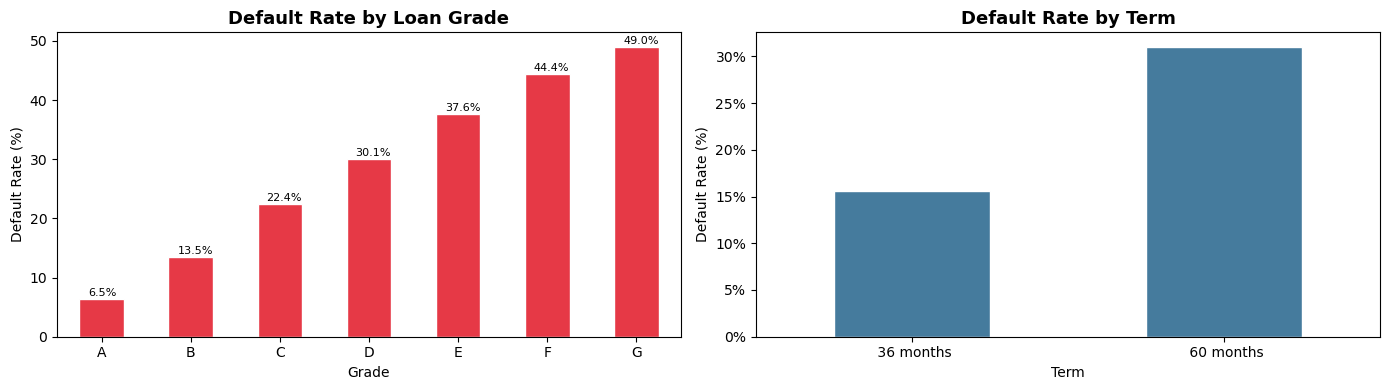

In [13]:
# ── Default rate by loan grade ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

grade_dr = df.groupby('grade')['target'].mean().sort_index() * 100
grade_dr.plot(kind='bar', ax=axes[0], color='#E63946', edgecolor='white')
axes[0].set_title('Default Rate by Loan Grade', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x()+0.1, p.get_height()+0.5), fontsize=8)

# Default Rate by grade
df.groupby('term')['target'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color='#457B9D', edgecolor='white'
)
axes[1].set_title('Default Rate by Term', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Term')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
# plt.show()
plt.savefig("Default rate by grade and term.png", dpi=600)
print('Insight: Lower-grade loans (E, F, G) have significantly higher default rates.')

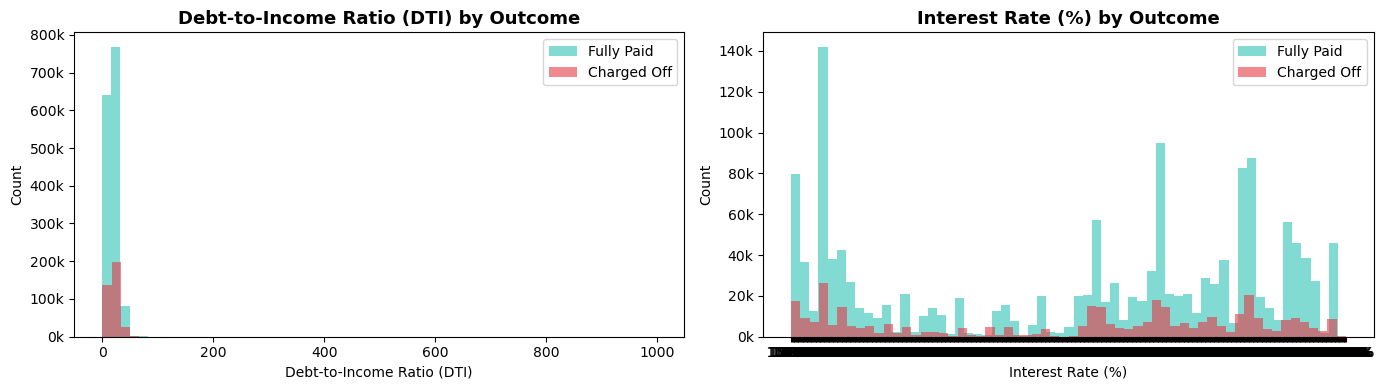

Insight: Defaulted loans tend to have higher DTI and higher interest rates.


In [14]:
# ── DTI Distribution: Defaulted vs Repaid ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label in zip(
    axes,
    ['dti', 'int_rate'],
    ['Debt-to-Income Ratio (DTI)', 'Interest Rate (%)']
):
    ax.hist(df[df['target']==0][col].dropna(), bins=60, alpha=0.6, label='Fully Paid', color='#2EC4B6')
    ax.hist(df[df['target']==1][col].dropna(), bins=60, alpha=0.6, label='Charged Off', color='#E63946')
    ax.set_title(f'{label} by Outcome', fontsize=13, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.show()
print('Insight: Defaulted loans tend to have higher DTI and higher interest rates.')

Insight: 2007–2009 vintages show elevated defaults (GFC). Later vintages mature at lower rates.


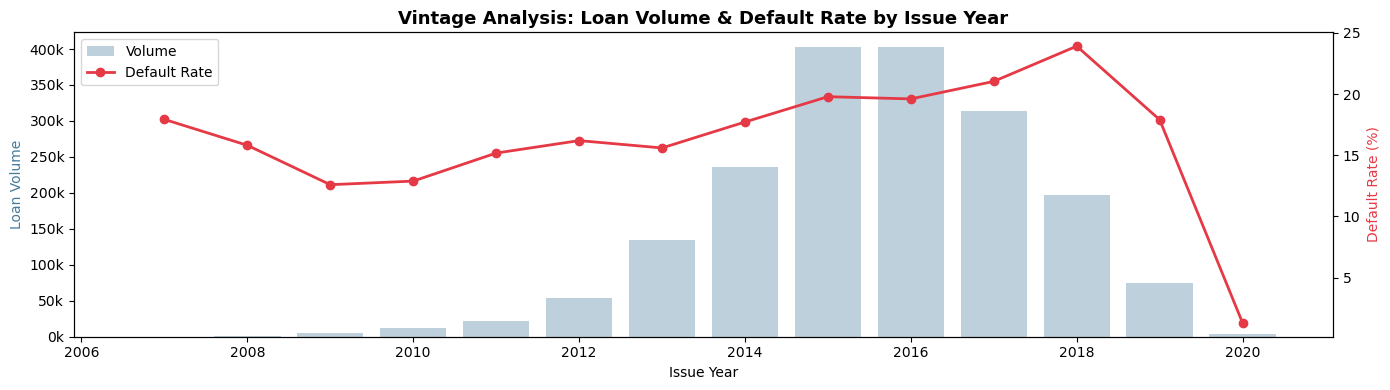

In [15]:
# ── Vintage analysis: Default rate by issue year ────────────
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['issue_year'] = df['issue_d'].dt.year

vintage = df.groupby('issue_year')['target'].agg(['mean','count']).reset_index()
vintage.columns = ['Year', 'Default_Rate', 'Volume']
vintage = vintage[vintage['Volume'] > 100]

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(vintage['Year'], vintage['Volume'], alpha=0.35, color='#457B9D', label='Volume')
ax2.plot(vintage['Year'], vintage['Default_Rate']*100, 'o-', color='#E63946', linewidth=2, label='Default Rate')
ax1.set_xlabel('Issue Year')
ax1.set_ylabel('Loan Volume', color='#457B9D')
ax2.set_ylabel('Default Rate (%)', color='#E63946')
ax1.set_title('Vintage Analysis: Loan Volume & Default Rate by Issue Year', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
# plt.show()
plt.savefig("Vinatge default.png", dpi = 600)
print('Insight: 2007–2009 vintages show elevated defaults (GFC). Later vintages mature at lower rates.')

In [46]:
ORIGINATION_FEATURES = [
    'loan_amnt', 'int_rate', 'installment',
    'annual_inc', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'fico_range_low', 'fico_range_high',
    'grade', 'sub_grade', 'emp_length',
    'home_ownership', 'purpose', 'term', 'issue_year'
]

# Keep only columns that exist in this dataset version
FEATURES = [f for f in ORIGINATION_FEATURES if f in df.columns]
print(f'Features used ({len(FEATURES)}): {FEATURES}')

df_model = df[FEATURES + ['target']].copy()

# ── Derived features ─────────────────────────────────────────
df_model['fico_avg'] = (df['fico_range_low'].fillna(0) + df['fico_range_high'].fillna(0)) / 2
df_model['log_annual_inc'] = np.log1p(df_model['annual_inc'])
df_model['log_revol_bal']  = np.log1p(df_model['revol_bal'])
# df_model['payment_to_income'] = df_model['installment'] / (df_model['annual_inc'] / 12 + 1)

# ── Clean int_rate / revol_util (remove % sign if present) ───
for col in ['int_rate', 'revol_util']:
    if df_model[col].dtype == object:
        df_model[col] = df_model[col].str.replace('%','').astype(float)

# ── term: extract numeric months ────────────────────────────
if df_model['term'].dtype == object:
    df_model['term'] = df_model['term'].str.extract(r'(\d+)').astype(float)

# ── emp_length: ordinal encode ────────────────────────────────
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10, 'n/a': -1
}
if 'emp_length' in df_model.columns:
    df_model['emp_length'] = df_model['emp_length'].map(emp_map).fillna(-1)

# ── One-hot encode categoricals ───────────────────────────────
CAT_COLS = ['grade', 'sub_grade', 'home_ownership', 'purpose']
CAT_COLS = [c for c in CAT_COLS if c in df_model.columns]
df_model = pd.get_dummies(df_model, columns=CAT_COLS, drop_first=True)
df_model = df_model.drop(columns=['annual_inc'])
print(f'\nFinal model dataframe shape: {df_model.shape}')
print(f'Missing values: {df_model.isnull().sum().sum():,}')

Features used (21): ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'fico_range_low', 'fico_range_high', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'purpose', 'term', 'issue_year']

Final model dataframe shape: (1860331, 78)
Missing values: 2,507


### 4.1.2 Feature Selection Principle 2: Variance Inflation Factor
#### Rule of Thumb for VIF
* **If VIF >= 5 or 10**: Drop such features

In [49]:
def calculate_vif(X: pd.DataFrame, threshold: float = 10.0) -> pd.DataFrame:
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LinearRegression

    # Keep numeric only and impute
    X_num = X.select_dtypes(include=[np.number]).copy()
    imp   = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imp.fit_transform(X_num), columns=X_num.columns)

    def _vif_series(df: pd.DataFrame) -> pd.Series:
        vifs = {}
        for col in df.columns:
            y_col   = df[col].values
            X_other = df.drop(columns=[col]).values
            r2 = LinearRegression().fit(X_other, y_col).score(X_other, y_col)
            vifs[col] = 1 / (1 - min(r2, 0.9999))
        return pd.Series(vifs)

    # Full VIF table
    print('Computing VIF for all features...')
    vif_full = _vif_series(X_imp).sort_values(ascending=False)

    vif_df = pd.DataFrame({'feature': vif_full.index, 'vif': vif_full.values.round(2)})
    vif_df['flag'] = vif_df['vif'].apply(
        lambda v: '🔴 Severe' if v > 10 else '🟡 High' if v > 5 else '🟢 OK'
    )

    # Iterative removal above threshold
    cols, removed, iteration = list(X_imp.columns), [], 0
    while True:
        iteration += 1
        vifs     = _vif_series(X_imp[cols])
        max_vif  = vifs.max()
        max_feat = vifs.idxmax()
        if max_vif <= threshold:
            break
        print(f'  Iteration {iteration}: removing "{max_feat}" (VIF={max_vif:.1f})')
        cols.remove(max_feat)
        removed.append(max_feat)

    print(f'\nRemoved {len(removed)} features: {removed if removed else "none"}')
    print(f'Retained {len(cols)} features with VIF ≤ {threshold}')

    return vif_df, cols


# Run
X_for_vif = df_model.drop(columns=['target'])
vif_result, selected_features = calculate_vif(X_for_vif, threshold=10.0)
print(vif_result.to_string(index=False))

Computing VIF for all features...
  Iteration 1: removing "fico_range_low" (VIF=10000.0)
  Iteration 2: removing "fico_range_high" (VIF=10000.0)
  Iteration 3: removing "loan_amnt" (VIF=56.6)

Removed 3 features: ['fico_range_low', 'fico_range_high', 'loan_amnt']
Retained 16 features with VIF ≤ 10.0
        feature      vif     flag
       fico_avg 10000.00 🔴 Severe
fico_range_high 10000.00 🔴 Severe
 fico_range_low 10000.00 🔴 Severe
      loan_amnt    56.58 🔴 Severe
    installment    49.57 🔴 Severe
           term     6.41   🟡 High
       int_rate     2.62     🟢 OK
       open_acc     2.32     🟢 OK
      total_acc     2.18     🟢 OK
  log_revol_bal     2.17     🟢 OK
     revol_util     2.10     🟢 OK
 log_annual_inc     1.57     🟢 OK
      revol_bal     1.57     🟢 OK
            dti     1.22     🟢 OK
 inq_last_6mths     1.13     🟢 OK
        pub_rec     1.08     🟢 OK
     issue_year     1.08     🟢 OK
    delinq_2yrs     1.08     🟢 OK
     emp_length     1.06     🟢 OK


In [51]:
# print(selected_features)
df_model2 = df_model[selected_features + ['target']].copy()
print(df_model2.shape)

(1860331, 17)


### 4.1.3 Feature Selection Principle: Information Value (IV)
#### Rule of Thumb for Information Value (IV)

* **< 0.02**: Useless for prediction
* **0.02 to 0.1**: Weak predictive power
* **0.1 to 0.3**: Medium predictive power
* **0.3 to 0.5**: Strong predictive power
* **> 0.5**: Suspiciously strong (may indicate data leakage)

In [54]:
### Function to automacatilly calculate IV of features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec


# ── Constants ─────────────────────────────────────────────────────────────────

IV_LABELS = [
    (0.02, "Useless"),
    (0.10, "Weak"),
    (0.30, "Medium"),
    (0.50, "Strong"),
    (np.inf, "Very Strong (check for leakage)"),
]

IV_COLORS = {
    "Useless":                        "#94A3B8",
    "Weak":                           "#F0A500",
    "Medium":                         "#2EC4B6",
    "Strong":                         "#1B4F72",
    "Very Strong (check for leakage)":"#E63946",
}


def iv_strength(iv: float) -> str:
    for threshold, label in IV_LABELS:
        if iv < threshold:
            return label
    return IV_LABELS[-1][1]


# ── Core: WoE / IV for a single feature ──────────────────────────────────────

def _compute_iv_discrete(
    series: pd.Series,
    target: pd.Series,
    smoothing: float = 0.5,
) -> pd.DataFrame:
    """Compute WoE & IV for a discrete/categorical feature."""
    data = pd.DataFrame({"feature": series.fillna("Missing").astype(str), "target": target})

    total_events     = (data["target"] == 1).sum()
    total_non_events = (data["target"] == 0).sum()

    grp = (
        data.groupby("feature")["target"]
        .agg(n_total="count", n_events="sum")
        .reset_index()
    )
    grp["n_non_events"] = grp["n_total"] - grp["n_events"]
    grp["event_rate"]   = grp["n_events"] / grp["n_total"]

    grp["dist_events"]     = (grp["n_events"]     + smoothing) / (total_events     + smoothing)
    grp["dist_non_events"] = (grp["n_non_events"] + smoothing) / (total_non_events + smoothing)

    grp["woe"]          = np.log(grp["dist_events"] / grp["dist_non_events"])
    grp["iv_component"] = (grp["dist_events"] - grp["dist_non_events"]) * grp["woe"]

    grp = grp.rename(columns={"feature": "bin"})
    return grp


def _compute_iv_continuous(
    series: pd.Series,
    target: pd.Series,
    n_bins: int = 10,
    strategy: str = "quantile",
    smoothing: float = 0.5,
) -> pd.DataFrame:
    """
    Compute WoE & IV for a continuous feature by binning it first.

    strategy: "quantile" (equal-frequency) or "uniform" (equal-width)
    """
    data = pd.DataFrame({"feature": series, "target": target}).dropna(subset=["feature"])
    missing_mask = series.isna()
    has_missing  = missing_mask.any()

    total_events     = (target == 1).sum()
    total_non_events = (target == 0).sum()

    # Bin
    try:
        if strategy == "quantile":
            data["bin"] = pd.qcut(data["feature"], q=n_bins, duplicates="drop").astype(str)
        else:
            data["bin"] = pd.cut(data["feature"], bins=n_bins, duplicates="drop").astype(str)
    except Exception:
        # Fallback: fewer bins if not enough unique values
        unique_vals = data["feature"].nunique()
        n_bins_adj  = min(n_bins, unique_vals)
        data["bin"] = pd.qcut(data["feature"], q=n_bins_adj, duplicates="drop").astype(str)

    grp = (
        data.groupby("bin")["target"]
        .agg(n_total="count", n_events="sum")
        .reset_index()
    )

    # Add Missing bin if present
    if has_missing:
        miss_target = target[missing_mask]
        miss_row = pd.DataFrame([{
            "bin":       "Missing",
            "n_total":   len(miss_target),
            "n_events":  (miss_target == 1).sum(),
        }])
        grp = pd.concat([grp, miss_row], ignore_index=True)

    grp["n_non_events"] = grp["n_total"] - grp["n_events"]
    grp["event_rate"]   = grp["n_events"] / grp["n_total"]

    grp["dist_events"]     = (grp["n_events"]     + smoothing) / (total_events     + smoothing)
    grp["dist_non_events"] = (grp["n_non_events"] + smoothing) / (total_non_events + smoothing)

    grp["woe"]          = np.log(grp["dist_events"] / grp["dist_non_events"])
    grp["iv_component"] = (grp["dist_events"] - grp["dist_non_events"]) * grp["woe"]

    return grp


# ── Main public function ──────────────────────────────────────────────────────

def calculate_iv(
    df: pd.DataFrame,
    features: list = None,
    target: str = "target",
    cat_features: list = None,
    num_features: list = None,
    n_bins: int = 10,
    bin_strategy: str = "quantile",
    smoothing: float = 0.5,
    cat_threshold: int = 20,
    exclude: list = None,
) -> pd.DataFrame:
    """
    Calculate Information Value (IV) for a list of features.

    Automatically detects whether each feature is discrete or continuous,
    computes WoE per bin/category, and returns a ranked IV summary table.

    Parameters
    ----------
    df            : Input DataFrame.
    features      : List of feature columns to evaluate. If None, uses all
                    columns except `target`.
    target        : Binary target column name (1 = event, 0 = non-event).
    cat_features  : Explicitly mark these columns as categorical.
    num_features  : Explicitly mark these columns as numerical.
    n_bins        : Number of bins for continuous features (default 10).
    bin_strategy  : "quantile" (equal-frequency) or "uniform" (equal-width).
    smoothing     : Laplace smoothing constant to avoid log(0) (default 0.5).
    cat_threshold : Columns with <= this many unique values are treated as
                    categorical (default 20).
    exclude       : Columns to skip regardless of `features`.

    Returns
    -------
    iv_df : pd.DataFrame sorted by IV descending with columns:
            [feature, iv, strength, feature_type, n_bins_used,
             missing_pct, n_unique]
    """
    # ── Input validation ──────────────────────────────────────────────
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not in DataFrame.")
    if df[target].nunique() != 2:
        raise ValueError(f"Target '{target}' must be binary (0 / 1).")

    total_events     = (df[target] == 1).sum()
    total_non_events = (df[target] == 0).sum()
    if total_events == 0 or total_non_events == 0:
        raise ValueError("Target has only one class — IV is undefined.")

    # ── Feature list ─────────────────────────────────────────────────
    exclude   = set(exclude or []) | {target}
    if features is None:
        features = [c for c in df.columns if c not in exclude]
    else:
        features = [c for c in features if c not in exclude]

    cat_features = set(cat_features or [])
    num_features = set(num_features or [])

    # ── Compute IV per feature ────────────────────────────────────────
    records = []
    detail_map = {}   # feature -> bin-level DataFrame (for downstream use)

    for feat in features:
        series = df[feat]
        miss_pct = series.isna().mean() * 100
        n_unique = series.nunique()

        # Determine type
        if feat in cat_features:
            ftype = "categorical"
        elif feat in num_features:
            ftype = "continuous"
        elif pd.api.types.is_numeric_dtype(series) and n_unique > cat_threshold:
            ftype = "continuous"
        else:
            ftype = "categorical"

        try:
            if ftype == "categorical":
                bin_df = _compute_iv_discrete(series, df[target], smoothing=smoothing)
            else:
                bin_df = _compute_iv_continuous(
                    series, df[target],
                    n_bins=n_bins, strategy=bin_strategy, smoothing=smoothing
                )

            iv_total   = bin_df["iv_component"].sum()
            n_bins_used = len(bin_df)
            detail_map[feat] = bin_df

        except Exception as e:
            iv_total    = np.nan
            n_bins_used = np.nan
            print(f"  [WARN] Skipped '{feat}': {e}")

        records.append({
            "feature":      feat,
            "iv":           iv_total,
            "strength":     iv_strength(iv_total) if not np.isnan(iv_total) else "Error",
            "feature_type": ftype,
            "n_bins_used":  n_bins_used,
            "missing_pct":  round(miss_pct, 2),
            "n_unique":     n_unique,
        })

    iv_df = (
        pd.DataFrame(records)
        .dropna(subset=["iv"])
        .sort_values("iv", ascending=False)
        .reset_index(drop=True)
    )
    iv_df.index += 1   # 1-based rank
    iv_df.index.name = "rank"

    # Attach detail map as a non-index attribute for advanced use
    iv_df.attrs["detail"] = detail_map

    return iv_df


# ── Plotting ──────────────────────────────────────────────────────────────────

def plot_iv_summary(
    iv_df: pd.DataFrame,
    top_n: int = 30,
    figsize: tuple = (11, 7),
    show_thresholds: bool = True,
    title: str = "Information Value — Feature Ranking",
) -> None:
    """
    Horizontal bar chart of IV values, coloured by predictive strength.
    Threshold reference lines for Useless / Weak / Medium / Strong are shown.

    Parameters
    ----------
    iv_df           : Output from calculate_iv().
    top_n           : Maximum number of features to display.
    figsize         : Figure size.
    show_thresholds : Draw IV threshold reference lines.
    title           : Plot title.
    """
    plot_df = iv_df.head(top_n).copy().reset_index(drop=True)
    plot_df = plot_df.sort_values("iv", ascending=True)   # ascending for horizontal bar

    bar_colors = [IV_COLORS.get(s, "#94A3B8") for s in plot_df["strength"]]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("#F8FAFC")
    ax.grid(axis="x", color="#E2E8F0", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    bars = ax.barh(
        plot_df["feature"], plot_df["iv"],
        color=bar_colors, edgecolor="white", linewidth=0.6, zorder=3
    )

    # Value labels
    for bar, iv_val in zip(bars, plot_df["iv"]):
        ax.text(
            iv_val + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{iv_val:.4f}",
            va="center", ha="left", fontsize=8.5, color="#1E293B"
        )

    # Threshold reference lines
    if show_thresholds:
        thresholds = [(0.02, "Useless", "--"), (0.10, "Weak", ":"),
                      (0.30, "Medium",  "-."), (0.50, "Strong", "-")]
        for xval, label, ls in thresholds:
            if xval <= plot_df["iv"].max() * 1.15:
                ax.axvline(xval, color="#CBD5E1", linewidth=1.2,
                           linestyle=ls, zorder=2)
                ax.text(xval + 0.002, 0.5, label,
                        transform=ax.get_xaxis_transform(),
                        fontsize=7.5, color="#64748B", va="bottom")

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=c, label=l) for l, c in IV_COLORS.items()
    ]
    ax.legend(
        handles=legend_elements, title="Predictive Power",
        loc="lower right", fontsize=8, title_fontsize=8.5,
        framealpha=0.9, edgecolor="#CBD5E1"
    )

    ax.set_xlabel("Information Value (IV)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12, color="#0D1B2A")
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    plt.tight_layout()
    plt.show()


def plot_iv_bins(
    iv_df: pd.DataFrame,
    feature: str,
    figsize: tuple = (11, 5),
    show_table: bool = True,
) -> None:
    """
    Plot bin-level WoE and event rate for a single feature using the
    detail stored inside iv_df.attrs["detail"].

    Parameters
    ----------
    iv_df   : Output from calculate_iv().
    feature : Feature name to plot.
    """
    detail = iv_df.attrs.get("detail", {})
    if feature not in detail:
        raise KeyError(
            f"'{feature}' not found in IV detail. "
            "Make sure it was included in the calculate_iv() call."
        )

    bin_df   = detail[feature].copy()
    iv_total = bin_df["iv_component"].sum()
    label    = iv_strength(iv_total)

    # Colour bars by WoE sign
    bar_colors = [
        "#E63946" if w > 0.05 else "#2EC4B6" if w < -0.05 else "#94A3B8"
        for w in bin_df["woe"]
    ]

    if show_table:
        fig = plt.figure(figsize=(figsize[0], figsize[1] + 2.5), layout="constrained")
        gs  = GridSpec(2, 1, figure=fig, height_ratios=[figsize[1], 2.5], hspace=0.5)
        ax  = fig.add_subplot(gs[0])
        ax_tbl = fig.add_subplot(gs[1])
        ax_tbl.axis("off")
    else:
        fig, ax = plt.subplots(figsize=figsize)

    ax2 = ax.twinx()
    ax.set_facecolor("#F8FAFC")
    ax.grid(axis="y", color="#E2E8F0", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    x = np.arange(len(bin_df))
    bars = ax.bar(x, bin_df["woe"], width=0.55, color=bar_colors,
                  edgecolor="white", linewidth=0.8, zorder=3)
    ax.axhline(0, color="#64748B", linewidth=1.1, linestyle="--", zorder=2)

    # WoE labels
    for bar, val in zip(bars, bin_df["woe"]):
        offset = 0.02 if val >= 0 else -0.04
        ax.text(
            bar.get_x() + bar.get_width() / 2, val + offset,
            f"{val:+.2f}", ha="center",
            va="bottom" if val >= 0 else "top",
            fontsize=8.5, fontweight="bold", color="#1E293B"
        )

    # Event rate line
    ax2.plot(x, bin_df["event_rate"] * 100, color="#0D1B2A",
             marker="o", markersize=6, linewidth=2, zorder=4)
    for xi, er in zip(x, bin_df["event_rate"]):
        ax2.annotate(f"{er*100:.1f}%", (xi, er * 100),
                     textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=7.5, color="#0D1B2A")

    ax.set_xticks(x)
    ax.set_xticklabels(bin_df["bin"].tolist(), fontsize=9, rotation=20, ha="right")
    ax.set_ylabel("Weight of Evidence (WoE)", fontsize=10)
    ax.set_xlabel("Bin", fontsize=10)
    ax2.set_ylabel("Event Rate (%)", fontsize=10, color="#0D1B2A")
    ax2.tick_params(axis="y", labelcolor="#0D1B2A", labelsize=8.5)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

    ax.set_title(
        f"WoE by Bin — {feature}",
        fontsize=13, fontweight="bold", pad=12, color="#0D1B2A"
    )
    ax.text(
        0.98, 0.97, f"IV = {iv_total:.4f}  ({label})",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9.5, fontweight="bold", color="#0D1B2A",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#E2EAF4",
                  edgecolor="#CBD5E1", linewidth=0.8)
    )

    # Optional table
    if show_table:
        tbl = bin_df[["bin", "n_total", "n_events", "event_rate", "woe", "iv_component"]].copy()
        tbl["event_rate"]   = tbl["event_rate"].map(lambda v: f"{v*100:.1f}%")
        tbl["woe"]          = tbl["woe"].map(lambda v: f"{v:+.4f}")
        tbl["iv_component"] = tbl["iv_component"].map(lambda v: f"{v:.4f}")
        tbl.columns         = ["Bin", "N Total", "N Events", "Event Rate", "WoE", "IV Component"]

        table = ax_tbl.table(
            cellText=tbl.values, colLabels=tbl.columns,
            loc="center", cellLoc="center"
        )
        table.auto_set_font_size(False)
        table.set_fontsize(8.5)
        table.scale(1, 1.35)

        for j in range(len(tbl.columns)):
            table[0, j].set_facecolor("#0D1B2A")
            table[0, j].set_text_props(color="white", fontweight="bold")
        for i in range(1, len(tbl) + 1):
            bg = "#F8FAFC" if i % 2 == 0 else "#FFFFFF"
            for j in range(len(tbl.columns)):
                table[i, j].set_facecolor(bg)
            woe_val   = bin_df.iloc[i - 1]["woe"]
            woe_color = "#FEE2E2" if woe_val > 0.05 else "#D1FAE5" if woe_val < -0.05 else "#F1F5F9"
            table[i, 4].set_facecolor(woe_color)

        ax_tbl.set_title(
            f"Bin Summary  |  Total IV = {iv_total:.4f}  ({label})",
            fontsize=9.5, pad=6, color="#334155"
        )

    if not show_table:
        plt.tight_layout()
    plt.show()

### 4.1.3 Select Features based on Information Value

Step 1: Calculate IV for all features
             feature        iv strength feature_type  n_bins_used  missing_pct  n_unique
rank                                                                                    
1           int_rate  0.430908   Strong   continuous           10         0.00       684
2               term  0.163624   Medium  categorical            2         0.00         2
3           fico_avg  0.104671   Medium   continuous           10         0.00        40
4                dti  0.052532     Weak   continuous           11         0.06      9346
5        installment  0.039344     Weak   continuous           10         0.00     90807
6         issue_year  0.028383     Weak  categorical           14         0.00        14
7     inq_last_6mths  0.026745     Weak  categorical           10         0.00         9
8     log_annual_inc  0.024516     Weak   continuous           10         0.00     79173
9         revol_util  0.018129  Useless   continuous           11       

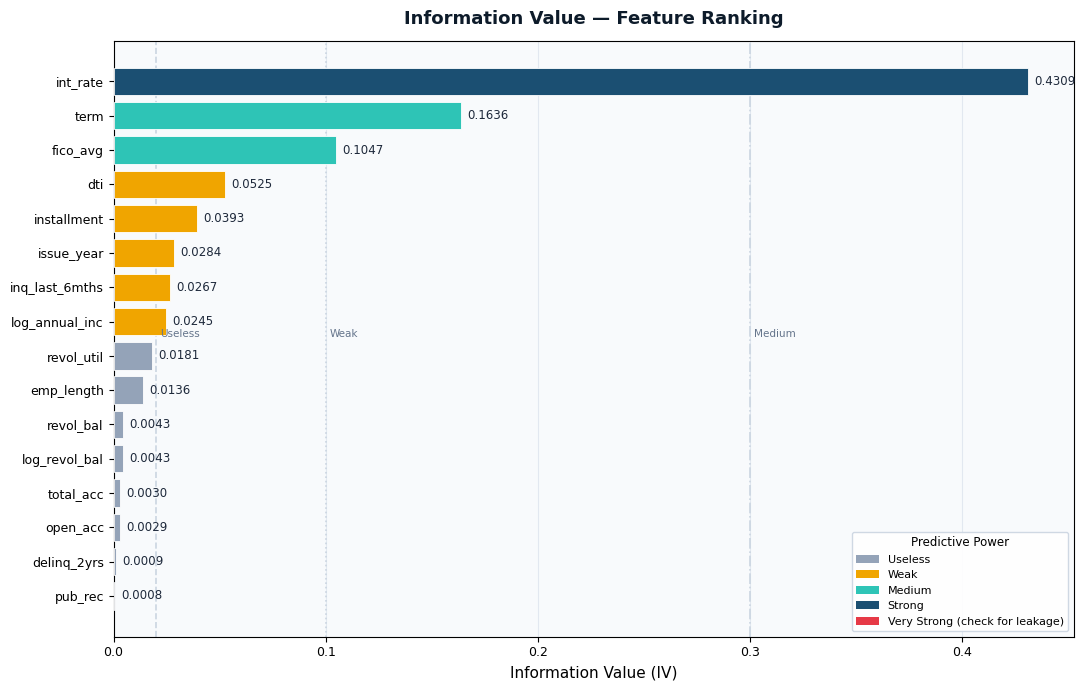

In [57]:
print("=" * 65)
print("Step 1: Calculate IV for all features")
print("=" * 65)

iv_result = calculate_iv(
    df_model2,
    target="target",
    n_bins=10,
    bin_strategy="quantile",
    cat_threshold=20
)

print(iv_result.to_string())

print("\nStep 2: Plot IV summary chart")
plot_iv_summary(iv_result, top_n=20)
# plt.savefig("Feature IV.png", dpi=600, bbox_inches="tight")

In [59]:
### Keep only useful features to reduce model complexity
final_feature = iv_result[iv_result['iv']>=0.02]['feature'].tolist()
print(final_feature)
print(len(final_feature))

['int_rate', 'term', 'fico_avg', 'dti', 'installment', 'issue_year', 'inq_last_6mths', 'log_annual_inc']
8


## 5. Modeling

### Approach
1. **Logistic Regression** — interpretable baseline, produces calibrated probabilities

### Class Imbalance
Lending Club data typically shows ~20% default rate. We handle this via:
- `class_weight='balanced'` in Logistic Regression (preferred for simplicity)

### Train/Test Split
Stratified 80/20 split to preserve class ratios.

In [62]:
# Prepare X, y
X = df_model2.drop(columns=['target'])
# Susbet 23 features with useful information value
X = X[final_feature]
y = df_model2['target']
RANDOM_STATE = 42
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print(f'Train default rate: {y_train.mean()*100:.1f}% | Test default rate: {y_test.mean()*100:.1f}%')

Train: 1,488,264 rows | Test: 372,067 rows
Train default rate: 19.5% | Test default rate: 19.5%


In [64]:
# ── Logistic Regression Pipeline ──────────────────────────────
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)
print(f'Logistic Regression AUC: {lr_auc:.4f}')

Logistic Regression AUC: 0.6999


## 6. Model Evaluation

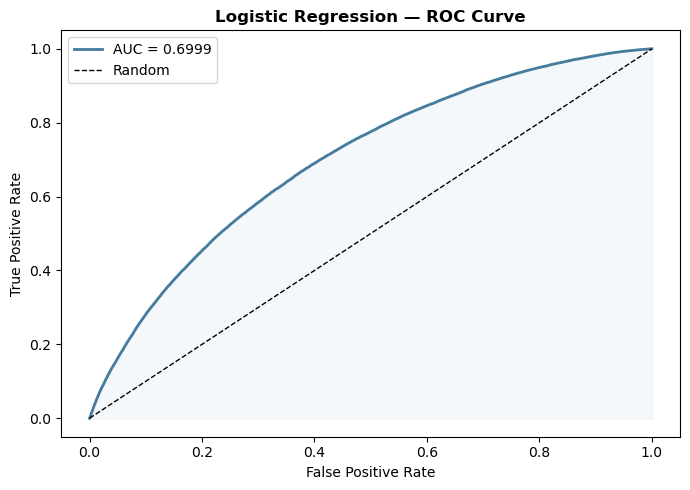

In [67]:
# ── Logistic Regression ROC Curve ─────────────────────────────
plt.figure(figsize=(7, 5))

fpr, tpr, _ = roc_curve(y_test, lr_proba)
auc = roc_auc_score(y_test, lr_proba)

plt.plot(fpr, tpr, color='#457B9D', linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.fill_between(fpr, tpr, alpha=0.05, color='#457B9D')

plt.title('Logistic Regression — ROC Curve', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
# plt.show()
plt.savefig("Logistic Regression - ROC Curve.png", dpi=600)

In [69]:
# ── KS Statistic ──────────────────────────────────────────────
def ks_statistic(y_true, y_prob):
    df_ks = pd.DataFrame({'y': y_true, 'p': y_prob}).sort_values('p', ascending=False)
    df_ks['cum_bad']  = (df_ks['y'] == 1).cumsum() / (df_ks['y'] == 1).sum()
    df_ks['cum_good'] = (df_ks['y'] == 0).cumsum() / (df_ks['y'] == 0).sum()
    df_ks['ks'] = abs(df_ks['cum_bad'] - df_ks['cum_good'])
    return df_ks['ks'].max()

# Calculate for Logistic Regression
lr_ks = ks_statistic(y_test.values, lr_proba)
lr_gini = 2 * lr_auc - 1

print('══════════════════════════════════════════')
print('  Logistic Regression Performance')
print('──────────────────────────────────────────')
print(f'  AUC-ROC           {lr_auc:.4f}')
print(f'  KS Statistic      {lr_ks:.4f}')
print(f'  Gini Coefficient  {lr_gini:.4f}')
print('══════════════════════════════════════════')
print('\nIndustry benchmarks: AUC > 0.70 = good, > 0.75 = strong')

══════════════════════════════════════════
  Logistic Regression Performance
──────────────────────────────────────────
  AUC-ROC           0.6999
  KS Statistic      0.2913
  Gini Coefficient  0.3998
══════════════════════════════════════════

Industry benchmarks: AUC > 0.70 = good, > 0.75 = strong


## 7. Feature Importance & Business Interpretation

We examine which features drive default risk most strongly. This allows us to answer:
> *"Are we lending to the right borrowers?"*

Interpretation: Positive coefficient = higher value → more default risk
E.g. higher int_rate → higher default risk | higher fico_avg → lower default risk


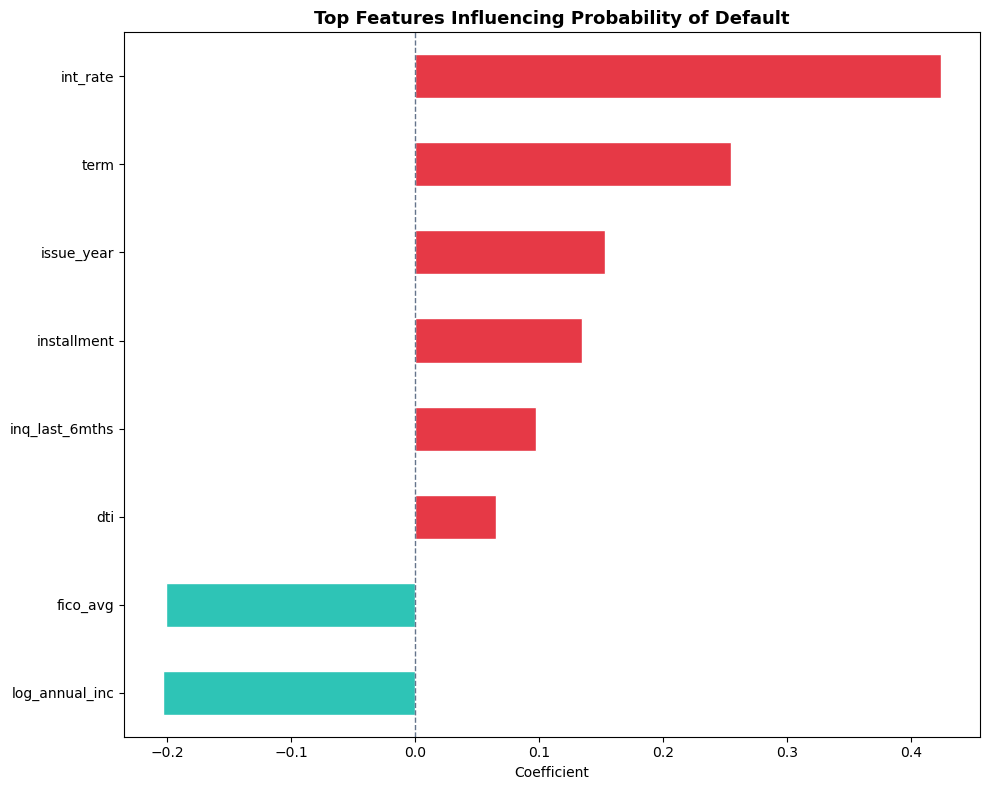

In [72]:
feature_names = X_train.columns.tolist()
lr_coefs = pd.Series(
    lr_pipeline.named_steps['model'].coef_[0],
    index=feature_names
).sort_values()

# top_features = pd.concat([lr_coefs.head(10), lr_coefs.tail(10)]).sort_values()
top_features = lr_coefs.sort_values()
colors = ['#2EC4B6' if v < 0 else '#E63946' for v in top_features]

fig, ax = plt.subplots(figsize=(10, 8))
top_features.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='#64748B', linewidth=1, linestyle='--')
ax.set_title('Top Features Influencing Probability of Default', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig("Features influencing PD.png", dpi=600, bbox_inches='tight')
print('Interpretation: Positive coefficient = higher value → more default risk')
print('E.g. higher int_rate → higher default risk | higher fico_avg → lower default risk')

In [76]:
print(lr_coefs)

log_annual_inc   -0.203455
fico_avg         -0.201049
dti               0.065363
inq_last_6mths    0.097467
installment       0.134151
issue_year        0.152922
term              0.254662
int_rate          0.424094
dtype: float64


## 8. Business Interpretation

### Key Findings

| Driver | Direction | Business Interpretation |
|--------|-----------|------------------------|
| **Interest Rate** | ↑ Risk | Higher-rate loans are priced riskier — and they actually default more |
| **Term (60 months)** | ↑ Risk | Longer-term loans carry higher default rates |
| **DTI (Debt-to-Income)** | ↑ Risk | Borrowers with high existing debt burden are more likely to default |
| **Loan Grade (E/F/G)** | ↑ Risk | LC's own grading system is informative |
| **FICO Score** | ↓ Risk | Higher credit scores strongly predict repayment |
| **Annual Income (log)** | ↓ Risk | Higher-income borrowers have more repayment capacity |


### Are We Lending to the Right Borrowers?

The model reveals that risk is **concentrated in predictable segments**:
- Grade E/F/G loans carry 2–4x the default rate of Grade A loans
- High DTI (>30) combined with low FICO (<650) is particularly risky
- 60-month loans have materially higher default rates than 36-month equivalents

**Recommended Actions:**
1. Apply PD score thresholds for underwriting: e.g. decline applications scoring in top decile
2. Review pricing adequacy: are interest rates compensating for actual default rates in Grade E/F?
3. Consider DTI caps or income verification requirements for high-DTI applicants
4. Monitor vintage performance annually — 2007–2009 vintages showed elevated charge-offs

## 9. Extensions (Optional)

### 9a. Cross-Validation

In [53]:
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv_scores = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'LR  CV AUC: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')

LR  CV AUC: 0.7043 ± 0.0009


### 9b. PD Score → Expected Loss Estimate

In [131]:
# Expected Loss = PD × LGD × EAD
# We don't have LGD/recovery data from origination — assume industry LGD = 55%
LGD_ASSUMPTION = 0.55

test_results = pd.DataFrame({
    'loan_amnt':    X_test['loan_amnt'].values if 'loan_amnt' in X_test.columns else np.nan,
    'pd_score':     gb_proba,
    'actual':       y_test.values
})

test_results['expected_loss'] = test_results['pd_score'] * LGD_ASSUMPTION * test_results['loan_amnt']
test_results['risk_tier'] = pd.qcut(test_results['pd_score'], 4, labels=['Low','Medium','High','Very High'])

print('Expected Loss by Risk Tier (test set):')
print(test_results.groupby('risk_tier').agg(
    Loans=('pd_score','count'),
    Avg_PD=('pd_score','mean'),
    Actual_DR=('actual','mean'),
    Avg_EL=('expected_loss','mean')
).round(3))

Expected Loss by Risk Tier (test set):
           Loans  Avg_PD  Actual_DR    Avg_EL
risk_tier                                    
Low        93017   0.069      0.062   504.692
Medium     93017   0.134      0.134   945.065
High       93016   0.210      0.211  1658.872
Very High  93017   0.368      0.371  3692.472
